# Практическая работа: воспроизведение и улучшение REAR для RAG

Цель ноутбука — воспроизвести ключевой inference-пайплайн статьи **REAR: A Relevance-Aware Retrieval-Augmented Framework for Open-Domain Question Answering** и затем проверить простые улучшения, которые можно реализовать на локальном компьютере без облачных сервисов.

Важное ограничение реализации: официальный код REAR рассчитан на `vLLM` и `bfloat16`, но на RTX 4080 Laptop 12 GB исходный запуск не помещается в VRAM. Поэтому в этой работе используется адаптированный backend:

- `transformers` вместо `vLLM`;
- `bitsandbytes 8-bit` вместо полного BF16;
- официальный checkpoint `RUCAIBox/rear-llama-7b-hf`;
- официальный `rel_score.weight`, извлечённый из checkpoint;
- те же ключевые параметры inference: `threshold = 13`, greedy decoding, `max_new_tokens = 20`.

Такой вариант не является новой моделью. Это перенос inference-логики REAR на более доступный backend с сохранением основной логики метода.


## 1. Установка зависимостей

Эта ячейка нужна только при первой настройке окружения. После успешной установки её можно не запускать каждый раз.

Почему версии зафиксированы:

- `torch==2.1.2+cu118` совместим с выбранными wheel-файлами и старым `vLLM==0.2.3`;
- `datasets==2.14.3` требует совместимый `pyarrow==12.0.1`;
- `bitsandbytes==0.43.1` оставляем, потому что более новые версии через `uv` тянут новый `torch`, `numpy>=2` и CUDA 13-зависимости, что ломает собранную рабочую связку.


In [1]:
# Запускать только при первой установке окружения.
# Если всё уже установлено и модель грузится, эту ячейку можно пропустить.

# !uv pip uninstall -y vllm xformers flash-attn torch torchvision torchaudio

# !uv pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118
# !uv pip install xformers==0.0.23.post1
# !uv pip install https://github.com/Dao-AILab/flash-attention/releases/download/v2.3.5/flash_attn-2.3.5+cu118torch2.1cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
# !uv pip install vllm==0.2.3 --torch-backend cu118
# !uv pip install transformers==4.38.0 datasets==2.14.3 accelerate==0.27.2 safetensors pyarrow==12.0.1 fsspec==2023.6.0 "numpy<2.0" ipywidgets setuptools bitsandbytes==0.43.1 huggingface_hub matplotlib
# !uv pip install nvidia-cusparse-cu11 nvidia-cublas-cu11 nvidia-cuda-runtime-cu11

## 2. Базовая структура проекта и проверка окружения

Здесь создаются рабочие папки и фиксируется seed. Это важно для отчёта: в нём нужно указать, на каком железе, с какими версиями библиотек и в каком режиме были получены результаты.


In [ ]:
from pathlib import Path
import os
import sys
import platform
import random
import json
import time
import math
import gc
import site
import ctypes
from collections import Counter

import numpy as np
import pandas as pd
import torch

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
REAR_DIR = PROJECT_DIR / "REAR"
MODEL_PATH = MODELS_DIR / "rear-llama-7b-hf"

for d in [DATA_DIR, RESULTS_DIR, MODELS_DIR]:
    d.mkdir(exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project dir:", PROJECT_DIR)
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("Torch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM, GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Project dir: /home/pimsoje/new/Practice
Python: 3.11.15 (main, Apr 14 2026, 14:28:36) [Clang 22.1.3 ]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Torch: 2.1.2+cu118
Torch CUDA: 11.8
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
VRAM, GB: 11.99


## 3. Загрузка официального репозитория REAR

Репозиторий нужен не только как источник кода, но и как доказательство того, что адаптированная реализация следует исходной логике. Ниже мы клонируем репозиторий, а затем отдельно проверяем параметры inference в официальных файлах.


In [3]:
import subprocess

if not REAR_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/RUCAIBox/REAR.git", str(REAR_DIR)],
        check=True
    )
else:
    print("REAR repository already exists:", REAR_DIR)


REAR repository already exists: /home/pimsoje/new/Practice/REAR


## 4. Загрузка checkpoint REAR

Если модель уже скачана в `models/rear-llama-7b-hf`, ячейка ничего заново не скачивает. Если модели нет, используется `snapshot_download`, который в Jupyter обычно показывает прогресс загрузки.


In [4]:
from huggingface_hub import snapshot_download

if not MODEL_PATH.exists() or not any(MODEL_PATH.glob("*.safetensors")):
    snapshot_download(
        repo_id="RUCAIBox/rear-llama-7b-hf",
        local_dir=str(MODEL_PATH),
        local_dir_use_symlinks=False,
    )
else:
    print("Model already exists:", MODEL_PATH)
    print("Safetensors files:", len(list(MODEL_PATH.glob("*.safetensors"))))


Model already exists: /home/pimsoje/new/Practice/models/rear-llama-7b-hf
Safetensors files: 2


## 5. Загрузка датасета `rear-eval`

Официальный README REAR указывает датасет `yhao-wang/rear-eval`. В практической работе лучше начать с малого `smoke`-набора на 20 примеров, а финальные результаты считать на 100, 300 или полном тестовом наборе.

Почему не сразу полный набор: один пример REAR reliability требует прогнать модель по нескольким документам. На локальной RTX 4080 Laptop это может занять десятки минут или часы. Это не методологическое ограничение, а ограничение времени вычислений. Для финального отчёта можно поставить `N_FINAL = len(dataset)` и запустить на ночь.


In [5]:
from datasets import load_dataset

# Если в окружении снова появится ошибка PyExtensionType, проверь версии:
# datasets==2.14.3 и pyarrow==12.0.1.
dataset = load_dataset("yhao-wang/rear-eval", split="test")
print(dataset)

example = dataset[0]
print("Question:", example["question"])
print("Reference:", example["reference"])
print("Number of ctxs:", len(example["ctxs"]))

N_SMOKE = 20
N_DEV = 20
N_TEST = 80
N_FINAL = 300

smoke_indices = list(range(0, min(N_SMOKE, len(dataset))))

# dev используется для первичной настройки threshold/weight/BM25
dev_indices = list(range(0, min(N_DEV, len(dataset))))

# holdout/test начинается после dev, чтобы не проверять улучшение на тех же примерах
test_indices = list(range(N_DEV, min(N_DEV + N_TEST, len(dataset))))

# final subset тоже лучше начинать после dev
final_indices = list(range(N_DEV, min(N_DEV + N_FINAL, len(dataset))))

# Полный датасет
full_indices = list(range(len(dataset)))
full_without_dev_indices = list(range(N_DEV, len(dataset)))

print("Smoke indices:", smoke_indices[:3], "...", smoke_indices[-3:])
print("Dev size:", len(dev_indices))
print("Test size:", len(test_indices))
print("Final size:", len(final_indices))
print("Full dataset size:", len(full_indices))
print("Full without dev size:", len(full_without_dev_indices))

with open(DATA_DIR / "rear_eval_smoke_20.json", "w", encoding="utf-8") as f:
    json.dump([dict(dataset[i]) for i in smoke_indices], f, ensure_ascii=False, indent=2)


Dataset({
    features: ['question', 'ctxs', 'reference'],
    num_rows: 27525
})
Question: who got the first nobel prize in physics
Reference: ['Wilhelm Conrad Röntgen']
Number of ctxs: 10
Smoke indices: [0, 1, 2] ... [17, 18, 19]
Dev size: 20
Test size: 80
Final size: 300
Full dataset size: 27525
Full without dev size: 27505


## 6. Проверка параметров в официальном коде REAR

Эта ячейка не влияет на расчёты. Она нужна для отчёта: показывает, откуда взяты `max_new_tokens = 20`, `temperature = 0.0`, `top_p = 1.0`, `top_k = -1`, а также `threshold = 13`.


In [6]:
for path in Path("REAR/rear/src").rglob("*.py"):
    text = path.read_text(encoding="utf-8", errors="ignore")
    if any(key in text for key in ["THRESHOLD", "max_tokens", "max_new_tokens", "SamplingParams", "temperature", "top_p", "top_k"]):
        print("\nFILE:", path)
        for i, line in enumerate(text.splitlines(), start=1):
            if any(key in line for key in ["THRESHOLD", "max_tokens", "max_new_tokens", "SamplingParams", "temperature", "top_p", "top_k"]):
                print(f"{i}: {line}")



FILE: REAR/rear/src/inf.py
5: from vllm import LLM, SamplingParams
23:     kwargs.update(dict(greedy=True, max_new_tokens=20))
32:     generation_config = SamplingParams(temperature=0.0, top_p=1.0, top_k=-1, max_tokens=20)

FILE: REAR/rear/src/routing.py
10: THRESHOLD = 13
54:         if res['score'] > THRESHOLD and (kc_score is None or kc_score < kc_tmp):

FILE: REAR/rear/src/vllm_rear.py
10:     from vllm.sampling_params import SamplingParams, SamplingType
32:         _get_temperatures,
33:         _get_top_p_top_k_min_p,
35:         _apply_top_p_top_k,
52: THRESHOLD, REL_TOK_ID, IRR_TOK_ID = None, None, None
91:         # Apply temperature scaling.
92:         temperatures = _get_temperatures(sampling_metadata)
93:         assert len(temperatures) == logits.shape[0]
94:         if any(t != 1.0 for t in temperatures):
95:             t = torch.tensor(temperatures,
102:         top_ps, top_ks, min_ps = _get_top_p_top_k_min_p(
104:         assert len(top_ps) == len(top_ks) == logits.s

## 7. Параметры адаптированной реализации

В официальном коде генерация ограничена `max_tokens=20`. Поэтому и здесь ответ ограничивается 20 новыми токенами.

Почему `max_input_tokens = 3968`, а не `4096 - 20 = 4076`: у модели контекст 4096, но в `transformers` и в токенизации остаются служебные токены, специальные маркеры REAR и небольшой запас безопасности. Поэтому берём `4096 - 128 = 3968`. Это безопаснее на 12 GB VRAM и не меняет сути эксперимента: ответ всё равно ограничен теми же 20 токенами, что и в оригинальной реализации.


In [7]:
ORIGINAL_THRESHOLD = 13.0
ORIGINAL_MAX_NEW_TOKENS = 20
MODEL_CONTEXT_TOKENS = 4096
SAFETY_MARGIN_TOKENS = 128
MAX_INPUT_TOKENS = MODEL_CONTEXT_TOKENS - SAFETY_MARGIN_TOKENS
CONSISTENCY_WEIGHT_ORIGINAL = 9.0

print("threshold:", ORIGINAL_THRESHOLD)
print("max_new_tokens:", ORIGINAL_MAX_NEW_TOKENS)
print("max_input_tokens:", MAX_INPUT_TOKENS)
print("consistency weight:", CONSISTENCY_WEIGHT_ORIGINAL)


threshold: 13.0
max_new_tokens: 20
max_input_tokens: 3968
consistency weight: 9.0


## 8. Загрузка модели через `transformers + bitsandbytes 8-bit`

Эта ячейка заменяет официальный backend `vLLM`. Возможные предупреждения:

- `BNB_CUDA_VERSION=118 ...` — ожидаемо, потому что мы принудительно выбираем CUDA 11.8 для bitsandbytes;
- `Special tokens have been added...` — не критично: checkpoint REAR уже содержит специальные токены, далее мы проверим их ID;
- предупреждения про несуществующие пути VS Code/Jupyter не влияют на inference.

Критерий успеха: модель загрузилась, `Memory footprint` около 6–8 GB, `Device map` указывает GPU.


In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

site_packages = Path(site.getsitepackages()[0])

cuda_lib_dirs = []
cuda_lib_dirs += [str(p) for p in site_packages.glob("nvidia/*/lib")]
cuda_lib_dirs += [str(site_packages / "torch" / "lib")]

old_ld = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = ":".join(cuda_lib_dirs + ([old_ld] if old_ld else []))
os.environ["BNB_CUDA_VERSION"] = "118"

def preload_cuda_lib(lib_name: str):
    found = list(site_packages.glob(f"**/{lib_name}*"))
    if found:
        ctypes.CDLL(str(found[0]), mode=ctypes.RTLD_GLOBAL)
        print("loaded:", found[0])
    else:
        print("not found:", lib_name)

for lib_name in ["libcudart.so.11.0", "libcublas.so.11", "libcusparse.so.11"]:
    preload_cuda_lib(lib_name)

gc.collect()
torch.cuda.empty_cache()

quantization_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
)

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_PATH), use_fast=False)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    str(MODEL_PATH),
    quantization_config=quantization_config_8bit,
    device_map="auto",
    max_memory={0: "10GiB", "cpu": "18GiB"},
    torch_dtype=torch.float16,
    trust_remote_code=False,
    low_cpu_mem_usage=True,
)

model.eval()

# На некоторых конфигурациях generation_config содержит лишнее поле,
# из-за которого печатается warning про add_special_tokens.
try:
    if hasattr(model.generation_config, "add_special_tokens"):
        delattr(model.generation_config, "add_special_tokens")
except Exception:
    pass

print("Loaded REAR checkpoint with transformers + bitsandbytes 8-bit")
print("Model class:", type(model))
print("Memory footprint GB:", round(model.get_memory_footprint() / 1024**3, 2))
if hasattr(model, "hf_device_map"):
    print("Device map:", model.hf_device_map)


loaded: /home/pimsoje/new/Practice/.venv/lib/python3.11/site-packages/nvidia/cuda_runtime/lib/libcudart.so.11.0
loaded: /home/pimsoje/new/Practice/.venv/lib/python3.11/site-packages/torch/lib/libcublas.so.11
loaded: /home/pimsoje/new/Practice/.venv/lib/python3.11/site-packages/nvidia/cusparse/lib/libcusparse.so.11


This can be used to load a bitsandbytes version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=
If you use the manual override make sure the right libcudart.so is in your LD_LIBRARY_PATH
For example by adding the following to your .bashrc: export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:<path_to_cuda_dir/lib64



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded REAR checkpoint with transformers + bitsandbytes 8-bit
Model class: <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
Memory footprint GB: 6.65
Device map: {'': 0}


## 9. Загрузка `rel_score.weight` и проверка специальных токенов

В REAR важна не только языковая модель, но и rank head (`rel_score`), который выдаёт числовую оценку релевантности документа вопросу. При загрузке через `AutoModelForCausalLM` этот слой не создаётся как отдельный модуль, поэтому мы извлекаем его из checkpoint вручную и используем в функции scoring.


In [9]:
from safetensors.torch import load_file

SPECIAL_TOKENS = {
    "begin_query": "<BEGIN_QUERY>",
    "generate_score": "<GENERATE_SCORE>",
    "relevant": "<RELEVANT>",
    "irrelevant": "<IRRELEVANT>",
}

special_ids = {
    name: tokenizer.convert_tokens_to_ids(token)
    for name, token in SPECIAL_TOKENS.items()
}

print("Special token ids:")
for name, token_id in special_ids.items():
    print(name, token_id, repr(tokenizer.decode([token_id], skip_special_tokens=False)))

for name, token_id in special_ids.items():
    assert token_id is not None and token_id != tokenizer.unk_token_id, f"Token not found: {name}"

def load_rel_score_weight(model_dir: Path) -> torch.Tensor:
    model_dir = Path(model_dir)
    index_path = model_dir / "model.safetensors.index.json"

    if index_path.exists():
        with open(index_path, "r", encoding="utf-8") as f:
            index = json.load(f)

        weight_file = index["weight_map"].get("rel_score.weight")
        if weight_file is None:
            raise KeyError("rel_score.weight not found in model.safetensors.index.json")

        tensor_path = model_dir / weight_file
        tensors = load_file(str(tensor_path))
        return tensors["rel_score.weight"]

    for tensor_path in model_dir.glob("*.safetensors"):
        tensors = load_file(str(tensor_path))
        if "rel_score.weight" in tensors:
            return tensors["rel_score.weight"]

    raise FileNotFoundError("rel_score.weight not found in local model files")

REL_SCORE_WEIGHT = load_rel_score_weight(MODEL_PATH).to(
    device=next(model.parameters()).device,
    dtype=torch.float16,
)

print("rel_score.weight shape:", tuple(REL_SCORE_WEIGHT.shape))


Special token ids:
begin_query 32000 '<BEGIN_QUERY>'
generate_score 32002 '<GENERATE_SCORE>'
relevant 32003 '<RELEVANT>'
irrelevant 32001 '<IRRELEVANT>'
rel_score.weight shape: (1, 4096)


## 10. Унифицированные функции токенизации и генерации

В этой секции задаётся единый способ генерации для всех методов:

- `do_sample=False` — greedy decoding;
- `max_new_tokens=20` — как в официальном REAR inference;
- вход при необходимости обрезается слева, потому что в prompt REAR вопрос и `<GENERATE_SCORE>` находятся в конце, а значит они сохраняются.


In [10]:
def get_model_device():
    for p in model.parameters():
        if p.device.type != "meta":
            return p.device
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def encode_to_ids(text: str, max_input_tokens: int | None = None, truncation_side: str = "left"):
    ids = tokenizer.encode(text, add_special_tokens=False)

    if max_input_tokens is not None and len(ids) > max_input_tokens:
        if truncation_side == "left":
            ids = ids[-max_input_tokens:]
        else:
            ids = ids[:max_input_tokens]

    return ids

def make_input_tensor(ids):
    device = get_model_device()
    input_ids = torch.tensor([ids], dtype=torch.long, device=device)
    attention_mask = torch.ones_like(input_ids)
    return input_ids, attention_mask

@torch.no_grad()
def generate_from_input_ids(
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor | None = None,
    max_new_tokens: int = ORIGINAL_MAX_NEW_TOKENS,
):
    generation_kwargs = {
        "input_ids": input_ids,
        "max_new_tokens": max_new_tokens,
        "do_sample": False,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }

    if attention_mask is not None:
        generation_kwargs["attention_mask"] = attention_mask

    output_ids = model.generate(**generation_kwargs)
    generated_ids = output_ids[0, input_ids.shape[1]:]

    return tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    ).strip()

def generate_text(
    prompt: str,
    max_new_tokens: int = ORIGINAL_MAX_NEW_TOKENS,
    max_input_tokens: int = MAX_INPUT_TOKENS,
):
    ids = encode_to_ids(prompt, max_input_tokens=max_input_tokens, truncation_side="left")
    input_ids, attention_mask = make_input_tensor(ids)
    return generate_from_input_ids(input_ids, attention_mask, max_new_tokens=max_new_tokens)

print(generate_text("Question: What is the capital of France?\nAnswer:", max_new_tokens=20))


Paris, France


## 11. Метрики EM/F1

Метрики считаются по классической схеме open-domain QA: нормализация регистра, удаление пунктуации и артиклей, затем Exact Match и token-level F1. Это соответствует смыслу метрик, используемых в статье.


In [11]:
import re
import string

def normalize_answer(s):
    if isinstance(s, list):
        s = s[0] if s else ""
    s = str(s)

    def lower(text):
        return text.lower()

    def remove_punc(text):
        return "".join(ch for ch in text if ch not in set(string.punctuation))

    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def exact_match_score(prediction, ground_truth):
    return int(normalize_answer(prediction) == normalize_answer(ground_truth))

def f1_score(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()

    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())

    if len(prediction_tokens) == 0 or len(ground_truth_tokens) == 0:
        return int(prediction_tokens == ground_truth_tokens)

    if num_same == 0:
        return 0.0

    precision = num_same / len(prediction_tokens)
    recall = num_same / len(ground_truth_tokens)
    return 2 * precision * recall / (precision + recall)

def metric_max_over_references(metric_fn, prediction, references):
    if isinstance(references, str):
        references = [references]
    return max(metric_fn(prediction, ref) for ref in references)

def score_prediction(prediction, reference):
    return {
        "em": metric_max_over_references(exact_match_score, prediction, reference),
        "f1": metric_max_over_references(f1_score, prediction, reference),
    }


## 12. Baseline: Direct RAG

Это базовая точка сравнения: документы просто кладутся в prompt, а модель генерирует ответ. В статье Direct Retrieval-Augmented QA использует top-10 документов. Здесь также по умолчанию `top_k=10`.

Чтобы вопрос не потерялся при обрезке длинного prompt, документы ставятся первыми, а вопрос и `Answer:` — в конце.


In [12]:
def build_direct_rag_prompt(example, top_k=10):
    question = example["question"]
    ctxs = example["ctxs"][:top_k]

    context_block = "\n\n".join(
        [f"[Document {i+1}]\n{ctx}" for i, ctx in enumerate(ctxs)]
    )

    prompt = f"""You are a question answering system.
Use the provided documents to answer the question.
Answer briefly and directly.

Documents:
{context_block}

Question:
{question}

Answer:"""
    return prompt

def run_direct_rag_eval(indices, top_k=10, max_new_tokens=ORIGINAL_MAX_NEW_TOKENS):
    from tqdm.auto import tqdm

    rows = []

    for i in tqdm(indices):
        ex = dataset[i]
        prompt = build_direct_rag_prompt(ex, top_k=top_k)

        start = time.time()
        pred = generate_text(prompt, max_new_tokens=max_new_tokens)
        elapsed = time.time() - start

        reference = ex["reference"]
        metrics = score_prediction(pred, reference)

        rows.append({
            "idx": i,
            "question": ex["question"],
            "prediction": pred,
            "reference": reference,
            "em": metrics["em"],
            "f1": metrics["f1"],
            "time_sec": elapsed,
            "top_k": top_k,
            "method": f"direct_rag_top{top_k}",
        })

    return pd.DataFrame(rows)

df_direct_smoke = run_direct_rag_eval(smoke_indices, top_k=10)
df_direct_smoke.to_csv(RESULTS_DIR / "direct_rag_top10_smoke.csv", index=False)

print("Direct RAG top-10 EM:", df_direct_smoke["em"].mean())
print("Direct RAG top-10 F1:", df_direct_smoke["f1"].mean())
df_direct_smoke.head()


  0%|          | 0/20 [00:00<?, ?it/s]

Direct RAG top-10 EM: 0.15
Direct RAG top-10 F1: 0.215


,idx,question,prediction,reference,em,f1,time_sec,top_k,method
0,0,who got the first nobel prize in physics,Wilhelm Röntgen,[Wilhelm Conrad Röntgen],0,0.8,1.183451,10,direct_rag_top10
1,1,when is the next deadpool movie being released,2018,"[May eighteen , 2018, May 18 , 2018]",0,0.5,1.217967,10,direct_rag_top10
2,2,which mode is used for short wave broadcast se...,,"[MFSK, Olivia]",0,0.0,0.468321,10,direct_rag_top10
3,3,the south west wind blows across nigeria between,,[till September],0,0.0,0.464847,10,direct_rag_top10
4,4,what does hp mean in war and order,,[hit points or health points],0,0.0,0.523998,10,direct_rag_top10


## 13. Adapted REAR: path-reliability routing

Это первая основная фаза REAR.

Логика:

1. Для каждой пары «документ + вопрос» строится prompt:  
   `{document}<BEGIN_QUERY>{question}<GENERATE_SCORE>`
2. Из hidden state позиции `<GENERATE_SCORE>` считается relevance score через `rel_score.weight`.
3. Если score выше threshold, добавляется токен `<RELEVANT>`, иначе `<IRRELEVANT>`.
4. Модель генерирует короткий ответ по каждому документу.
5. Финальным ответом path-reliability становится ответ документа с максимальным relevance score.


In [13]:
def build_rear_score_prompt(question: str, document: str) -> str:
    return f"{document}<BEGIN_QUERY>{question}<GENERATE_SCORE>"

@torch.no_grad()
def compute_rear_relevance_score(input_ids: torch.Tensor) -> float:
    outputs = model(
        input_ids=input_ids,
        output_hidden_states=True,
        use_cache=False,
        return_dict=True,
    )

    hidden_states = outputs.hidden_states[-1]
    gen_score_id = special_ids["generate_score"]
    positions = (input_ids[0] == gen_score_id).nonzero(as_tuple=True)[0]

    if len(positions) == 0:
        raise ValueError("<GENERATE_SCORE> token was not found in input_ids")

    score_position = int(positions[-1].item())
    rel_hidden = hidden_states[0, score_position, :].to(torch.float16)
    score = torch.matmul(rel_hidden, REL_SCORE_WEIGHT.T).squeeze().float().item()
    return score

def rear_generate_for_document(
    question: str,
    document: str,
    threshold: float = ORIGINAL_THRESHOLD,
    max_input_tokens: int = MAX_INPUT_TOKENS,
    max_new_tokens: int = ORIGINAL_MAX_NEW_TOKENS,
):
    prompt = build_rear_score_prompt(question, document)
    ids = encode_to_ids(prompt, max_input_tokens=max_input_tokens, truncation_side="left")
    input_ids, _ = make_input_tensor(ids)

    score = compute_rear_relevance_score(input_ids)

    relevance_token_id = special_ids["relevant"] if score > threshold else special_ids["irrelevant"]
    relevance_token = torch.tensor([[relevance_token_id]], dtype=torch.long, device=input_ids.device)
    rear_input_ids = torch.cat([input_ids, relevance_token], dim=1)
    attention_mask = torch.ones_like(rear_input_ids)

    pred = generate_from_input_ids(
        input_ids=rear_input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
    )

    return {
        "pred": pred,
        "score": score,
        "tag": "RELEVANT" if score > threshold else "IRRELEVANT",
    }

def rear_reliability_transformers(
    example: dict,
    threshold: float = ORIGINAL_THRESHOLD,
    max_input_tokens: int = MAX_INPUT_TOKENS,
    max_new_tokens: int = ORIGINAL_MAX_NEW_TOKENS,
):
    question = example["question"]
    ctxs = example["ctxs"]
    response = []

    for document in ctxs:
        response.append(
            rear_generate_for_document(
                question=question,
                document=document,
                threshold=threshold,
                max_input_tokens=max_input_tokens,
                max_new_tokens=max_new_tokens,
            )
        )

    best = max(response, key=lambda x: x["score"])
    pred = best["pred"]
    reference = example.get("reference")
    metrics = score_prediction(pred, reference) if reference is not None else {"em": None, "f1": None}

    return {
        "question": question,
        "reference": reference,
        "ctxs": ctxs,
        "response": response,
        "rely_answer": {
            "pred": pred,
            "EM": metrics["em"],
            "F1": metrics["f1"],
        },
    }


## 14. Sanity-check REAR на одном примере

Эта ячейка нужна перед массовым запуском: она показывает, что rank head выдаёт разные scores, что threshold работает, и что модель действительно генерирует ответы по разным документам.


In [14]:
example = dict(dataset[0])
rear_one = rear_reliability_transformers(example)

print("Question:", rear_one["question"])
print("Reference:", rear_one["reference"])
print("REAR reliability answer:", rear_one["rely_answer"]["pred"])

print("\nTop paths by relevance score:")
for item in sorted(rear_one["response"], key=lambda x: x["score"], reverse=True)[:5]:
    print(round(item["score"], 3), item["tag"], "|", item["pred"])

print("\nEM:", rear_one["rely_answer"]["EM"])
print("F1:", rear_one["rely_answer"]["F1"])


Question: who got the first nobel prize in physics
Reference: ['Wilhelm Conrad Röntgen']
REAR reliability answer: Wilhelm Röntgen

Top paths by relevance score:
20.719 RELEVANT | Wilhelm Röntgen
19.141 RELEVANT | Wilhelm Röntgen
19.141 RELEVANT | Wilhelm Röntgen
10.953 IRRELEVANT | Wilhelm Conrad Röntgen
8.664 IRRELEVANT | Wilhelm Conrad Röntgen

EM: 0
F1: 0.8


## 15. Оценка Adapted REAR reliability на подвыборке

Результаты сохраняются в JSON и CSV. JSON нужен для второй стадии — knowledge-consistency routing, потому что она использует уже сгенерированные ответы и relevance scores.


In [15]:
def evaluate_rear_reliability(indices, threshold: float = ORIGINAL_THRESHOLD, save_prefix: str = "smoke"):
    from tqdm.auto import tqdm

    detailed_results = []
    rows = []

    for i in tqdm(indices):
        ex = dict(dataset[i])
        start = time.time()
        result = rear_reliability_transformers(ex, threshold=threshold)
        elapsed = time.time() - start

        pred = result["rely_answer"]["pred"]
        reference = result["reference"]

        detailed_results.append(result)
        rows.append({
            "idx": i,
            "question": result["question"],
            "prediction": pred,
            "reference": reference,
            "em": result["rely_answer"]["EM"],
            "f1": result["rely_answer"]["F1"],
            "best_score": max(x["score"] for x in result["response"]),
            "threshold": threshold,
            "time_sec": elapsed,
            "method": "adapted_rear_reliability_transformers_8bit",
        })

    df = pd.DataFrame(rows)

    json_path = RESULTS_DIR / f"adapted_rear_reliability_{save_prefix}.json"
    csv_path = RESULTS_DIR / f"adapted_rear_reliability_{save_prefix}.csv"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(detailed_results, f, ensure_ascii=False, indent=2)

    df.to_csv(csv_path, index=False)

    print("Saved:", json_path)
    print("Saved:", csv_path)
    print("REAR reliability EM:", df["em"].mean())
    print("REAR reliability F1:", df["f1"].mean())
    print("Mean time:", df["time_sec"].mean())

    return df, detailed_results

rear_reliability_smoke_df, rear_reliability_smoke_details = evaluate_rear_reliability(
    smoke_indices,
    threshold=ORIGINAL_THRESHOLD,
    save_prefix="smoke",
)

rear_reliability_smoke_df.head()


  0%|          | 0/20 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_reliability_smoke.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_reliability_smoke.csv
REAR reliability EM: 0.4
REAR reliability F1: 0.5221428571428571
Mean time: 10.525996732711793


,idx,question,prediction,reference,em,f1,best_score,threshold,time_sec,method
0,0,who got the first nobel prize in physics,Wilhelm Röntgen,[Wilhelm Conrad Röntgen],0,0.800000,20.718750,13.0,10.967193,adapted_rear_reliability_transformers_8bit
1,1,when is the next deadpool movie being released,"May 18, 2018","[May eighteen , 2018, May 18 , 2018]",1,1.000000,18.343750,13.0,13.269495,adapted_rear_reliability_transformers_8bit
2,2,which mode is used for short wave broadcast se...,Amplitude modulation,"[MFSK, Olivia]",0,0.000000,18.625000,13.0,6.845326,adapted_rear_reliability_transformers_8bit
3,3,the south west wind blows across nigeria between,March and October,[till September],0,0.000000,11.718750,13.0,7.747510,adapted_rear_reliability_transformers_8bit
4,4,what does hp mean in war and order,Health Points,[hit points or health points],0,0.571429,11.664062,13.0,9.835156,adapted_rear_reliability_transformers_8bit


## 16. Adapted REAR: knowledge-consistency routing

Это вторая стадия REAR из официального inference.

Идея: среди документов с высоким relevance score выбирается не просто самый релевантный, а тот, чей ответ лучше согласуется с внутренними знаниями модели. В официальном коде это делается через обратную perplexity: чем легче модели сгенерировать этот ответ при принудительном `<IRRELEVANT>`, тем выше consistency.

Формула выбора в коде REAR:

`final_score = relevance_score + 9 * consistency_score`

при условии, что `relevance_score > 13`.


In [16]:
def answer_to_text(pred):
    if pred is None:
        return ""
    if isinstance(pred, list):
        return str(pred[0]) if pred else ""
    return str(pred)

@torch.no_grad()
def inverse_perplexity_for_pair(prefix: str, answer: str, max_input_tokens: int = MAX_INPUT_TOKENS) -> float:
    # Повторяет смысл official batch_perplexity:
    # input = prefix + answer[:-1], labels = answer.
    if answer == "":
        answer = "</s>"

    prefix_ids = tokenizer(prefix, add_special_tokens=False).input_ids
    answer_ids = tokenizer(answer, add_special_tokens=False).input_ids

    if not answer_ids:
        answer_ids = [tokenizer.eos_token_id]

    input_ids_list = prefix_ids + answer_ids[:-1]

    # Оставляем место под answer labels. Важно не потерять конец prefix,
    # где находятся <GENERATE_SCORE><IRRELEVANT>.
    max_prefix_part = max_input_tokens - len(answer_ids)
    if max_prefix_part > 0 and len(input_ids_list) > max_prefix_part:
        input_ids_list = input_ids_list[-max_prefix_part:]

    input_ids = torch.tensor([input_ids_list], dtype=torch.long, device=get_model_device())
    labels = torch.tensor(answer_ids, dtype=torch.long, device=get_model_device())

    outputs = model(input_ids=input_ids, use_cache=False, return_dict=True)
    logits = outputs.logits

    selected_logits = logits[0, -len(labels):, :].contiguous()
    loss = torch.nn.functional.cross_entropy(selected_logits, labels)
    return math.exp(-float(loss.item()))

def add_consistency_scores(
    result: dict,
    pred_mode: str = "full",
):
    """
    pred_mode='full' — использовать полный ответ. Это логически корректная адаптация.
    pred_mode='first_char' — repo-compatible режим для проверки строки dic['pred'][0] из официального кода.
    """
    question = result["question"]
    ctxs = result["ctxs"]
    response = result["response"]

    for ctx, item in zip(ctxs, response):
        pred = answer_to_text(item.get("pred", ""))

        if pred_mode == "first_char":
            answer_for_ppl = pred[0] if pred else ""
        elif pred_mode == "full":
            answer_for_ppl = pred
        else:
            raise ValueError("pred_mode must be 'full' or 'first_char'")

        prefix = f"<s>{ctx}<BEGIN_QUERY>{question}<GENERATE_SCORE><IRRELEVANT>"
        item["con"] = inverse_perplexity_for_pair(prefix, answer_for_ppl)
        item["con_pred_mode"] = pred_mode

    return result

def choose_consistency_answer(
    result: dict,
    threshold: float = ORIGINAL_THRESHOLD,
    consistency_weight: float = CONSISTENCY_WEIGHT_ORIGINAL,
):
    response = result["response"]
    kc_idx = None
    kc_score = None

    for idx, item in enumerate(response):
        if "con" not in item:
            raise ValueError("Consistency scores are missing. Run add_consistency_scores first.")

        candidate_score = item["score"] + consistency_weight * item["con"]

        if item["score"] > threshold and (kc_score is None or kc_score < candidate_score):
            kc_idx = idx
            kc_score = candidate_score

    if kc_idx is None:
        pred = result["rely_answer"]["pred"]
        source = "fallback_reliability"
    else:
        pred = response[kc_idx]["pred"]
        source = "knowledge_consistency"

    reference = result.get("reference")
    metrics = score_prediction(pred, reference) if reference is not None else {"em": None, "f1": None}

    result["con_answer"] = {
        "pred": pred,
        "EM": metrics["em"],
        "F1": metrics["f1"],
        "source": source,
        "selected_idx": kc_idx,
        "selected_score": kc_score,
        "threshold": threshold,
        "consistency_weight": consistency_weight,
    }
    return result

def evaluate_rear_consistency_from_details(
    details: list[dict],
    pred_mode: str = "full",
    threshold: float = ORIGINAL_THRESHOLD,
    consistency_weight: float = CONSISTENCY_WEIGHT_ORIGINAL,
    save_prefix: str = "smoke_full",
):
    from tqdm.auto import tqdm
    import copy

    out_details = []
    rows = []

    for result in tqdm(details):
        item = copy.deepcopy(result)
        start = time.time()
        item = add_consistency_scores(item, pred_mode=pred_mode)
        item = choose_consistency_answer(item, threshold=threshold, consistency_weight=consistency_weight)
        elapsed = time.time() - start

        out_details.append(item)
        rows.append({
            "question": item["question"],
            "prediction": item["con_answer"]["pred"],
            "reference": item["reference"],
            "em": item["con_answer"]["EM"],
            "f1": item["con_answer"]["F1"],
            "source": item["con_answer"]["source"],
            "selected_idx": item["con_answer"]["selected_idx"],
            "threshold": threshold,
            "consistency_weight": consistency_weight,
            "pred_mode": pred_mode,
            "time_sec": elapsed,
            "method": f"adapted_rear_consistency_{pred_mode}",
        })

    df = pd.DataFrame(rows)

    json_path = RESULTS_DIR / f"adapted_rear_consistency_{save_prefix}.json"
    csv_path = RESULTS_DIR / f"adapted_rear_consistency_{save_prefix}.csv"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(out_details, f, ensure_ascii=False, indent=2)

    df.to_csv(csv_path, index=False)

    print("Saved:", json_path)
    print("Saved:", csv_path)
    print("Consistency EM:", df["em"].mean())
    print("Consistency F1:", df["f1"].mean())
    print("Mean consistency time:", df["time_sec"].mean())

    return df, out_details


### Проверка спорного места в knowledge-consistency

В официальной реализации REAR на стадии consistency используется конструкция `dic["pred"][0]`. Так как `pred` после generation является строкой ответа, эта конструкция берёт только первый символ ответа, а не весь ответ. Ниже проверяется разница между режимом, максимально близким к официальному коду (`official_first_char`), и предлагаемым улучшением (`full_answer`).

In [17]:
import math
import torch
import torch.nn.functional as F
import pandas as pd

def conditional_likelihood_score(
    question: str,
    document: str,
    answer_text: str,
    max_input_tokens: int = 3968,
):
    """
    Считает условную вероятность ответа answer_text после REAR-prefix.

    Это нужно для демонстрации разницы:
    - official_first_char: answer_text = pred[0]
    - full_answer: answer_text = pred

    Чем выше score, тем легче модели сгенерировать этот answer_text
    после заданного документа и вопроса.
    """
    if answer_text is None or answer_text == "":
        answer_text = tokenizer.eos_token or "</s>"

    prefix = f"<s>{document}<BEGIN_QUERY>{question}<GENERATE_SCORE><IRRELEVANT>"

    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    answer_ids = tokenizer.encode(answer_text, add_special_tokens=False)

    if len(answer_ids) == 0:
        answer_ids = [tokenizer.eos_token_id]

    # Оставляем место под answer_ids.
    max_prefix_len = max_input_tokens - max(len(answer_ids) - 1, 0)
    if len(prefix_ids) > max_prefix_len:
        prefix_ids = prefix_ids[-max_prefix_len:]

    # Для autoregressive LM:
    # logits на последнем токене prefix предсказывают первый токен answer.
    input_ids_list = prefix_ids + answer_ids[:-1]

    input_ids = torch.tensor(
        [input_ids_list],
        dtype=torch.long,
        device=get_model_device()
    )

    target_ids = torch.tensor(
        answer_ids,
        dtype=torch.long,
        device=get_model_device()
    )

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=torch.ones_like(input_ids),
            return_dict=True
        )

        logits = outputs.logits[0, -len(target_ids):, :].contiguous()

        loss = F.cross_entropy(
            logits.float(),
            target_ids,
            reduction="mean"
        )

    # exp(-loss) — удобная нормированная оценка: чем больше, тем лучше.
    return math.exp(-loss.item())


def inspect_original_pred0_vs_full_answer(
    reliability_result: dict,
    top_n: int = 10,
    alpha: float = 9.0,
):
    """
    Показывает, что реально происходит в consistency,
    если использовать pred[0] и если использовать полный pred.
    """
    question = reliability_result["question"]
    ctxs = reliability_result["ctxs"]
    response = reliability_result["response"]

    rows = []

    for i, (document, item) in enumerate(zip(ctxs, response)):
        pred = item.get("pred", "")
        pred_first_char = pred[0] if pred else ""
        pred_full = pred

        con_first_char = conditional_likelihood_score(
            question=question,
            document=document,
            answer_text=pred_first_char,
        )

        con_full_answer = conditional_likelihood_score(
            question=question,
            document=document,
            answer_text=pred_full,
        )

        relevance_score = float(item["score"])

        rows.append({
            "doc_id": i,
            "relevance_score": relevance_score,
            "tag": item.get("tag"),
            "pred_full": pred_full,
            "pred_first_char": pred_first_char,
            "first_char_len": len(pred_first_char),
            "full_answer_len": len(pred_full),
            "con_official_first_char": con_first_char,
            "con_improved_full_answer": con_full_answer,
            "final_official_first_char": relevance_score + alpha * con_first_char,
            "final_improved_full_answer": relevance_score + alpha * con_full_answer,
        })

    df = pd.DataFrame(rows)

    print("Question:")
    print(question)

    print("\nReference:")
    print(reliability_result.get("reference"))

    print("\nReliability answer:")
    print(reliability_result["rely_answer"]["pred"])

    best_rel = df.sort_values("relevance_score", ascending=False).iloc[0]
    best_official = df.sort_values("final_official_first_char", ascending=False).iloc[0]
    best_improved = df.sort_values("final_improved_full_answer", ascending=False).iloc[0]

    print("\n=== What official dic['pred'][0] does ===")
    print("Full prediction from best reliability path:")
    print(repr(best_rel["pred_full"]))
    print("dic['pred'][0] gives only:")
    print(repr(best_rel["pred_first_char"]))

    print("\n=== Selected paths ===")
    print("Best by relevance_score:")
    print(
        "doc_id =", int(best_rel["doc_id"]),
        "| score =", round(float(best_rel["relevance_score"]), 4),
        "| pred =", repr(best_rel["pred_full"])
    )

    print("\nBest by official_first_char consistency:")
    print(
        "doc_id =", int(best_official["doc_id"]),
        "| final =", round(float(best_official["final_official_first_char"]), 4),
        "| first_char =", repr(best_official["pred_first_char"]),
        "| pred =", repr(best_official["pred_full"])
    )

    print("\nBest by improved_full_answer consistency:")
    print(
        "doc_id =", int(best_improved["doc_id"]),
        "| final =", round(float(best_improved["final_improved_full_answer"]), 4),
        "| pred =", repr(best_improved["pred_full"])
    )

    display_cols = [
        "doc_id",
        "relevance_score",
        "tag",
        "pred_full",
        "pred_first_char",
        "con_official_first_char",
        "con_improved_full_answer",
        "final_official_first_char",
        "final_improved_full_answer",
    ]

    return df[display_cols].sort_values(
        "relevance_score",
        ascending=False
    ).head(top_n)


# Берём первый результат reliability, который уже был посчитан.
# Если rear_details_20 ещё нет, сначала запусти evaluate_rear_reliability(...).
df_pred0_demo = inspect_original_pred0_vs_full_answer(
    reliability_result=rear_reliability_smoke_details[0],
    top_n=10,
    alpha=9.0,
)

df_pred0_demo

Question:
who got the first nobel prize in physics

Reference:
['Wilhelm Conrad Röntgen']

Reliability answer:
Wilhelm Röntgen

=== What official dic['pred'][0] does ===
Full prediction from best reliability path:
'Wilhelm Röntgen'
dic['pred'][0] gives only:
'W'

=== Selected paths ===
Best by relevance_score:
doc_id = 0 | score = 20.7188 | pred = 'Wilhelm Röntgen'

Best by official_first_char consistency:
doc_id = 0 | final = 20.7189 | first_char = 'W' | pred = 'Wilhelm Röntgen'

Best by improved_full_answer consistency:
doc_id = 4 | final = 26.2912 | pred = 'Wilhelm Röntgen'


,doc_id,relevance_score,tag,pred_full,pred_first_char,con_official_first_char,con_improved_full_answer,final_official_first_char,final_improved_full_answer
0,0,20.718750,RELEVANT,Wilhelm Röntgen,W,0.000016,0.611581,20.718893,26.222975
4,4,19.140625,RELEVANT,Wilhelm Röntgen,W,0.000096,0.794507,19.141488,26.291186
5,5,19.140625,RELEVANT,Wilhelm Röntgen,W,0.000096,0.794507,19.141488,26.291186
8,8,10.953125,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000054,0.846191,10.953610,18.568844
3,3,8.664062,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000028,0.836193,8.664311,16.189799
1,1,8.359375,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000018,0.849731,8.359534,16.006953
2,2,8.242188,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000012,0.859504,8.242297,15.977726
9,9,8.242188,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000041,0.840927,8.242558,15.810530
7,7,8.218750,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000005,0.911763,8.218798,16.424613
6,6,7.468750,IRRELEVANT,Wilhelm Conrad Röntgen,W,0.000041,0.833191,7.469120,14.967469


### Сравнение режимов consistency на выборке

После проверки одного примера необходимо оценить, влияет ли proposed full-answer consistency на итоговые метрики. Для этого сравниваются три режима: исходная reliability-стадия, consistency в режиме официальной реализации `pred[0]` и модифицированный режим `full_answer`.

In [18]:
def apply_consistency_mode_to_reliability_result(
    reliability_result: dict,
    mode: str = "official_first_char",
    alpha: float = 9.0,
    threshold: float = 13.0,
    max_input_tokens: int = 3968,
):
    question = reliability_result["question"]
    ctxs = reliability_result["ctxs"]
    response = reliability_result["response"]

    updated_response = []

    for document, item in zip(ctxs, response):
        pred = item.get("pred", "")

        if mode == "official_first_char":
            answer_text = pred[0] if pred else ""
        elif mode == "full_answer":
            answer_text = pred
        else:
            raise ValueError("mode must be 'official_first_char' or 'full_answer'")

        con = conditional_likelihood_score(
            question=question,
            document=document,
            answer_text=answer_text,
            max_input_tokens=max_input_tokens,
        )

        item_new = dict(item)
        item_new["con"] = con
        item_new["final_score"] = float(item["score"]) + alpha * con
        item_new["consistency_mode"] = mode
        updated_response.append(item_new)

    # Повторяем логику REAR: consistency выбирает только среди путей выше threshold.
    candidates = [
        item for item in updated_response
        if float(item["score"]) > threshold
    ]

    if len(candidates) == 0:
        # Если нет релевантных путей, fallback к reliability.
        best = max(updated_response, key=lambda x: float(x["score"]))
    else:
        best = max(candidates, key=lambda x: float(x["final_score"]))

    pred = best["pred"]
    reference = reliability_result["reference"]

    em = metric_max_over_references(exact_match_score, pred, reference)
    f1 = metric_max_over_references(f1_score, pred, reference)

    return {
        "question": question,
        "reference": reference,
        "prediction": pred,
        "em": em,
        "f1": f1,
        "selected_score": best["score"],
        "selected_final_score": best["final_score"],
        "selected_con": best["con"],
        "mode": mode,
        "selected_pred_first_char": pred[0] if pred else "",
    }


def compare_consistency_modes(
    reliability_details: list[dict],
    alpha: float = 9.0,
    threshold: float = 13.0,
):
    rows = []

    for i, rel_result in enumerate(reliability_details):
        reliability_pred = rel_result["rely_answer"]["pred"]
        reference = rel_result["reference"]

        rows.append({
            "idx": i,
            "mode": "reliability_only",
            "prediction": reliability_pred,
            "reference": reference,
            "em": metric_max_over_references(exact_match_score, reliability_pred, reference),
            "f1": metric_max_over_references(f1_score, reliability_pred, reference),
        })

        for mode in ["official_first_char", "full_answer"]:
            result = apply_consistency_mode_to_reliability_result(
                rel_result,
                mode=mode,
                alpha=alpha,
                threshold=threshold,
            )

            rows.append({
                "idx": i,
                "mode": mode,
                "prediction": result["prediction"],
                "reference": result["reference"],
                "em": result["em"],
                "f1": result["f1"],
                "selected_score": result["selected_score"],
                "selected_final_score": result["selected_final_score"],
                "selected_con": result["selected_con"],
            })

    df = pd.DataFrame(rows)

    summary = (
        df
        .groupby("mode", as_index=False)
        .agg(
            n=("idx", "count"),
            em=("em", "mean"),
            f1=("f1", "mean"),
        )
        .sort_values("f1", ascending=False)
    )

    return df, summary


df_consistency_compare_smoke, summary_consistency_compare_smoke = compare_consistency_modes(
    rear_reliability_smoke_details,
    alpha=9.0,
    threshold=13.0,
)

summary_consistency_compare_smoke

,mode,n,em,f1
0,full_answer,20,0.45,0.572143
1,official_first_char,20,0.40,0.547143
2,reliability_only,20,0.40,0.522143


In [19]:
pivot_predictions = df_consistency_compare_smoke.pivot_table(
    index="idx",
    columns="mode",
    values="prediction",
    aggfunc="first"
).reset_index()

changed_rows = pivot_predictions[
    (pivot_predictions["official_first_char"] != pivot_predictions["full_answer"]) |
    (pivot_predictions["reliability_only"] != pivot_predictions["full_answer"])
]

changed_rows

mode,idx,full_answer,official_first_char,reliability_only
1,1,2018,2018,"May 18, 2018"
11,11,Pyotr Ilyich Tchaikovsky,Tchaikovsky,Tchaikovsky
19,19,Yaya Touré,Yaya Touré,Mohamed Salah


## 17. Запуск knowledge-consistency на smoke-подвыборке

Сначала запускаем логически корректный вариант `pred_mode='full'`, где consistency считается по полному ответу. Это ближе к смыслу статьи: проверяется согласованность именно сгенерированного ответа, а не одного символа.


In [20]:
rear_consistency_smoke_df, rear_consistency_smoke_details = evaluate_rear_consistency_from_details(
    rear_reliability_smoke_details,
    pred_mode="full",
    threshold=ORIGINAL_THRESHOLD,
    consistency_weight=CONSISTENCY_WEIGHT_ORIGINAL,
    save_prefix="smoke_full",
)

rear_consistency_smoke_df.head()


  0%|          | 0/20 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_smoke_full.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_smoke_full.csv
Consistency EM: 0.45
Consistency F1: 0.5721428571428572
Mean consistency time: 1.9165350556373597


,question,prediction,reference,em,f1,source,selected_idx,threshold,consistency_weight,pred_mode,time_sec,method
0,who got the first nobel prize in physics,Wilhelm Röntgen,[Wilhelm Conrad Röntgen],0,0.800000,knowledge_consistency,4.0,13.0,9.0,full,1.924562,adapted_rear_consistency_full
1,when is the next deadpool movie being released,2018,"[May eighteen , 2018, May 18 , 2018]",0,0.500000,knowledge_consistency,4.0,13.0,9.0,full,1.973745,adapted_rear_consistency_full
2,which mode is used for short wave broadcast se...,Amplitude modulation,"[MFSK, Olivia]",0,0.000000,knowledge_consistency,0.0,13.0,9.0,full,1.899605,adapted_rear_consistency_full
3,the south west wind blows across nigeria between,March and October,[till September],0,0.000000,fallback_reliability,NaN,13.0,9.0,full,1.930001,adapted_rear_consistency_full
4,what does hp mean in war and order,Health Points,[hit points or health points],0,0.571429,fallback_reliability,NaN,13.0,9.0,full,1.929923,adapted_rear_consistency_full


## Улучшение: Answer-level aggregation

В REAR каждый документ формирует отдельный reasoning path. Если несколько разных документов приводят к одинаковому или почти одинаковому ответу, это можно рассматривать как дополнительное подтверждение. Поэтому ответы группируются после нормализации, а итоговый score группы складывается из лучшего path-score и бонуса за количество поддерживающих путей.

In [21]:
from collections import defaultdict


def normalize_for_support(text: str):
    text = str(text).lower().strip()
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = "".join(ch for ch in text if ch not in string.punctuation)
    text = " ".join(text.split())
    return text

def normalize_answer_key(text: str):
    return normalize_for_support(text)


def evaluate_answer_aggregation_selector(
    details: list[dict],
    threshold: float,
    consistency_weight: float,
    support_weight: float,
):
    rows = []

    for detail in details:
        groups = defaultdict(list)

        for item in detail["response"]:
            pred = str(item.get("pred", "")).strip()

            if not pred:
                continue

            relevance_score = float(item.get("score", 0.0))

            if relevance_score <= threshold:
                continue

            consistency_score = float(item.get("con", 0.0))
            path_score = relevance_score + consistency_weight * consistency_score

            answer_key = normalize_answer_key(pred)

            groups[answer_key].append({
                "pred": pred,
                "path_score": path_score,
                "relevance_score": relevance_score,
                "consistency_score": consistency_score,
            })

        if not groups:
            pred = detail["rely_answer"]["pred"]
            selected_mode = "fallback_reliability"
            selected_support = 1
            selected_group_score = None
        else:
            best_group = None
            best_group_score = None

            for answer_key, items in groups.items():
                best_path = max(items, key=lambda x: x["path_score"])
                support = len(items)

                group_score = best_path["path_score"] + support_weight * math.log1p(support)

                if best_group_score is None or group_score > best_group_score:
                    best_group_score = group_score
                    best_group = {
                        "answer_key": answer_key,
                        "pred": best_path["pred"],
                        "support": support,
                        "group_score": group_score,
                        "best_path_score": best_path["path_score"],
                    }

            pred = best_group["pred"]
            selected_mode = "answer_aggregation"
            selected_support = best_group["support"]
            selected_group_score = best_group["group_score"]

        metrics = score_prediction(pred, detail["reference"])

        rows.append({
            "question": detail["question"],
            "reference": detail["reference"],
            "prediction": pred,
            "em": metrics["em"],
            "f1": metrics["f1"],
            "threshold": threshold,
            "consistency_weight": consistency_weight,
            "support_weight": support_weight,
            "selected_mode": selected_mode,
            "selected_support": selected_support,
            "selected_group_score": selected_group_score,
        })

    return pd.DataFrame(rows)


def grid_search_answer_aggregation(details: list[dict]):
    rows = []

    threshold_grid = [8, 10, 12, 13, 14, 16]
    consistency_weight_grid = [6, 9, 12]
    support_weight_grid = [0.0, 0.25, 0.5, 1.0, 2.0, 3.0]

    for threshold in threshold_grid:
        for consistency_weight in consistency_weight_grid:
            for support_weight in support_weight_grid:
                df = evaluate_answer_aggregation_selector(
                    details,
                    threshold=threshold,
                    consistency_weight=consistency_weight,
                    support_weight=support_weight,
                )

                rows.append({
                    "threshold": threshold,
                    "consistency_weight": consistency_weight,
                    "support_weight": support_weight,
                    "EM": df["em"].mean(),
                    "F1": df["f1"].mean(),
                    "mean_support": df["selected_support"].mean(),
                })

    grid_df = (
        pd.DataFrame(rows)
        .sort_values(["F1", "EM"], ascending=False)
        .reset_index(drop=True)
    )

    return grid_df


answer_agg_grid_smoke = grid_search_answer_aggregation(
    rear_consistency_smoke_details
)

answer_agg_grid_smoke.to_csv(
    RESULTS_DIR / "answer_aggregation_grid_smoke.csv",
    index=False
)

display(answer_agg_grid_smoke.head(10))

best_answer_agg = answer_agg_grid_smoke.iloc[0].to_dict()
best_answer_agg

,threshold,consistency_weight,support_weight,EM,F1,mean_support
0,8,6,0.00,0.50,0.597143,3.70
1,8,9,1.00,0.50,0.597143,3.75
2,8,12,3.00,0.50,0.597143,3.95
3,10,6,0.00,0.50,0.597143,2.95
4,12,6,0.00,0.50,0.597143,2.00
5,13,6,0.00,0.50,0.597143,1.70
6,14,6,0.00,0.50,0.597143,1.55
7,14,9,2.00,0.50,0.597143,1.55
8,8,6,0.25,0.45,0.572143,3.80
9,8,6,0.50,0.45,0.572143,3.80


{'threshold': 8.0,
 'consistency_weight': 6.0,
 'support_weight': 0.0,
 'EM': 0.5,
 'F1': 0.5971428571428572,
 'mean_support': 3.7}

## Улучшение: Reciprocal Rank Fusion вместо прямого сложения score

Прямое сложение REAR score, consistency и BM25 может быть нестабильным, потому что эти величины имеют разные масштабы. Поэтому проверяется RRF: каждый сигнал превращается в ранжирование документов, после чего ранги объединяются. Это снижает риск того, что один плохо откалиброванный score испортит итоговый выбор.

## RRF + nothing

In [22]:
import copy


def answer_support_features(answer: str, document: str):
    """
    Оценивает, насколько сгенерированный ответ подтверждается текстом документа.

    Используются два простых признака:
    1. exact_support — входит ли нормализованный ответ целиком в документ;
    2. token_overlap — какая доля токенов ответа есть в документе.
    """

    answer_norm = normalize_for_support(answer)
    document_norm = normalize_for_support(document)

    if not answer_norm:
        return {
            "answer_exact_support": 0.0,
            "answer_token_overlap": 0.0,
            "answer_support": 0.0,
        }

    exact_support = 1.0 if answer_norm in document_norm else 0.0

    answer_tokens = set(answer_norm.split())
    document_tokens = set(document_norm.split())

    if not answer_tokens:
        token_overlap = 0.0
    else:
        token_overlap = len(answer_tokens & document_tokens) / len(answer_tokens)

    return {
        "answer_exact_support": float(exact_support),
        "answer_token_overlap": float(token_overlap),
        "answer_support": float(exact_support + token_overlap),
    }


def make_desc_ranks(values):
    """
    Строит ранги по убыванию значения.

    Чем больше значение, тем лучше ранг.
    Лучший объект получает rank = 1.
    """

    order = sorted(
        range(len(values)),
        key=lambda i: values[i],
        reverse=True,
    )

    ranks = [0] * len(values)

    for rank, idx in enumerate(order, start=1):
        ranks[idx] = rank

    return ranks


def add_answer_support_to_details(details: list[dict]):
    """
    Добавляет answer_support без BM25.

    answer_support показывает, насколько сгенерированный ответ
    лексически подтверждается выбранным документом.
    """

    enriched = copy.deepcopy(details)

    for detail in enriched:
        ctxs = detail["ctxs"]
        response = detail["response"]

        for i, item in enumerate(response):
            pred = str(item.get("pred", "")).strip()
            support = answer_support_features(pred, ctxs[i])
            item.update(support)

    return enriched


def evaluate_rrf_no_bm25_selector(
    details: list[dict],
    threshold: float,
    rrf_k: float,
    score_weight: float,
    consistency_weight: float,
    answer_support_weight: float,
):
    """
    RRF без BM25.

    Используются только:
    - REAR relevance score;
    - full-answer consistency score;
    - answer_support.
    """

    enriched = add_answer_support_to_details(details)
    rows = []

    for detail in enriched:
        response = detail["response"]

        relevance_values = [float(item.get("score", 0.0)) for item in response]
        consistency_values = [float(item.get("con", 0.0)) for item in response]
        answer_support_values = [float(item.get("answer_support", 0.0)) for item in response]

        relevance_ranks = make_desc_ranks(relevance_values)
        consistency_ranks = make_desc_ranks(consistency_values)
        answer_support_ranks = make_desc_ranks(answer_support_values)

        best_item = None
        best_rrf_score = None

        for i, item in enumerate(response):
            relevance_score = float(item.get("score", 0.0))

            if relevance_score <= threshold:
                continue

            rrf_score = (
                score_weight / (rrf_k + relevance_ranks[i])
                + consistency_weight / (rrf_k + consistency_ranks[i])
                + answer_support_weight / (rrf_k + answer_support_ranks[i])
            )

            if best_rrf_score is None or rrf_score > best_rrf_score:
                best_rrf_score = rrf_score
                best_item = item

        if best_item is None:
            pred = detail["rely_answer"]["pred"]
            selected_mode = "fallback_reliability"
        else:
            pred = best_item["pred"]
            selected_mode = "rrf_no_bm25"

        metrics = score_prediction(pred, detail["reference"])

        rows.append({
            "question": detail["question"],
            "reference": detail["reference"],
            "prediction": pred,
            "em": metrics["em"],
            "f1": metrics["f1"],
            "threshold": threshold,
            "rrf_k": rrf_k,
            "score_weight": score_weight,
            "consistency_weight": consistency_weight,
            "answer_support_weight": answer_support_weight,
            "selected_mode": selected_mode,
            "selected_rrf_score": best_rrf_score,
        })

    return pd.DataFrame(rows)


def grid_search_rrf_no_bm25(details: list[dict]):
    rows = []

    threshold_grid = [8, 10, 12, 13, 14, 16]
    rrf_k_grid = [10, 30, 60]

    weight_configs = [
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 0.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 0.5,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 1.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 2.0,
        },
        {
            "score_weight": 2.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 1.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 2.0,
            "answer_support_weight": 1.0,
        },
    ]

    for threshold in threshold_grid:
        for rrf_k in rrf_k_grid:
            for config in weight_configs:
                df = evaluate_rrf_no_bm25_selector(
                    details,
                    threshold=threshold,
                    rrf_k=rrf_k,
                    **config,
                )

                rows.append({
                    "threshold": threshold,
                    "rrf_k": rrf_k,
                    **config,
                    "EM": df["em"].mean(),
                    "F1": df["f1"].mean(),
                })

    grid_df = (
        pd.DataFrame(rows)
        .sort_values(["F1", "EM"], ascending=False)
        .reset_index(drop=True)
    )

    return grid_df


rrf_no_bm25_grid_smoke = grid_search_rrf_no_bm25(
    rear_consistency_smoke_details
)

rrf_no_bm25_grid_smoke.to_csv(
    RESULTS_DIR / "rrf_no_bm25_grid_smoke.csv",
    index=False,
)

display(rrf_no_bm25_grid_smoke.head(10))

best_rrf_no_bm25 = rrf_no_bm25_grid_smoke.iloc[0].to_dict()
best_rrf_no_bm25

,threshold,rrf_k,score_weight,consistency_weight,answer_support_weight,EM,F1
0,8,10,1.0,1.0,1.0,0.5,0.597143
1,8,10,1.0,1.0,2.0,0.5,0.597143
2,8,30,1.0,1.0,2.0,0.5,0.597143
3,10,10,1.0,1.0,1.0,0.5,0.597143
4,10,10,1.0,1.0,2.0,0.5,0.597143
5,10,30,1.0,1.0,2.0,0.5,0.597143
6,10,60,1.0,1.0,2.0,0.5,0.597143
7,12,10,1.0,1.0,1.0,0.5,0.597143
8,12,10,1.0,1.0,2.0,0.5,0.597143
9,12,30,1.0,1.0,2.0,0.5,0.597143


{'threshold': 8.0,
 'rrf_k': 10.0,
 'score_weight': 1.0,
 'consistency_weight': 1.0,
 'answer_support_weight': 1.0,
 'EM': 0.5,
 'F1': 0.5971428571428572}

## RRF + Answer-level aggregation

Эта версия сначала считает RRF-score для каждого path, а потом группирует одинаковые ответы.

In [23]:
def normalize_answer_key(text: str):
    return normalize_for_support(text)


def evaluate_rrf_answer_aggregation_selector(
    details: list[dict],
    threshold: float,
    rrf_k: float,
    score_weight: float,
    consistency_weight: float,
    answer_support_weight: float,
    aggregation_weight: float,
):
    """
    RRF + Answer-level aggregation без BM25.

    Логика:
    1. Для каждого path считаются ранги по:
       - REAR relevance score;
       - consistency score;
       - answer_support.
    2. RRF объединяет эти ранги.
    3. Затем одинаковые ответы группируются.
    4. Группа получает небольшой бонус за повторяемость ответа.
    """

    enriched = add_answer_support_to_details(details)
    rows = []

    for detail in enriched:
        response = detail["response"]

        relevance_values = [float(item.get("score", 0.0)) for item in response]
        consistency_values = [float(item.get("con", 0.0)) for item in response]
        answer_support_values = [float(item.get("answer_support", 0.0)) for item in response]

        relevance_ranks = make_desc_ranks(relevance_values)
        consistency_ranks = make_desc_ranks(consistency_values)
        answer_support_ranks = make_desc_ranks(answer_support_values)

        groups = defaultdict(list)

        for i, item in enumerate(response):
            relevance_score = float(item.get("score", 0.0))

            if relevance_score <= threshold:
                continue

            pred = str(item.get("pred", "")).strip()

            if not pred:
                continue

            rrf_score = (
                score_weight / (rrf_k + relevance_ranks[i])
                + consistency_weight / (rrf_k + consistency_ranks[i])
                + answer_support_weight / (rrf_k + answer_support_ranks[i])
            )

            answer_key = normalize_answer_key(pred)

            groups[answer_key].append({
                "pred": pred,
                "path_idx": i,
                "rrf_score": rrf_score,
                "relevance_score": relevance_score,
                "consistency_score": float(item.get("con", 0.0)),
                "answer_support": float(item.get("answer_support", 0.0)),
            })

        if not groups:
            pred = detail["rely_answer"]["pred"]
            selected_mode = "fallback_reliability"
            selected_support = 1
            selected_group_score = None
            selected_best_path_rrf = None
        else:
            best_group = None
            best_group_score = None

            for answer_key, items in groups.items():
                best_path = max(items, key=lambda x: x["rrf_score"])
                support = len(items)

                group_score = best_path["rrf_score"] + aggregation_weight * math.log1p(support)

                if best_group_score is None or group_score > best_group_score:
                    best_group_score = group_score
                    best_group = {
                        "pred": best_path["pred"],
                        "support": support,
                        "group_score": group_score,
                        "best_path_rrf": best_path["rrf_score"],
                    }

            pred = best_group["pred"]
            selected_mode = "rrf_answer_level_aggregation"
            selected_support = best_group["support"]
            selected_group_score = best_group["group_score"]
            selected_best_path_rrf = best_group["best_path_rrf"]

        metrics = score_prediction(pred, detail["reference"])

        rows.append({
            "question": detail["question"],
            "reference": detail["reference"],
            "prediction": pred,
            "em": metrics["em"],
            "f1": metrics["f1"],
            "threshold": threshold,
            "rrf_k": rrf_k,
            "score_weight": score_weight,
            "consistency_weight": consistency_weight,
            "answer_support_weight": answer_support_weight,
            "aggregation_weight": aggregation_weight,
            "selected_mode": selected_mode,
            "selected_support": selected_support,
            "selected_group_score": selected_group_score,
            "selected_best_path_rrf": selected_best_path_rrf,
            "method": "rrf_answer_level_aggregation",
        })

    return pd.DataFrame(rows)


def grid_search_rrf_answer_aggregation(details: list[dict]):
    rows = []

    threshold_grid = [8, 10, 12, 13, 14, 16]
    rrf_k_grid = [10, 30, 60]

    weight_configs = [
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 0.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 0.5,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 1.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 2.0,
        },
        {
            "score_weight": 2.0,
            "consistency_weight": 1.0,
            "answer_support_weight": 1.0,
        },
        {
            "score_weight": 1.0,
            "consistency_weight": 2.0,
            "answer_support_weight": 1.0,
        },
    ]

    aggregation_weight_grid = [0.0, 0.25, 0.5, 1.0, 2.0]

    for threshold in threshold_grid:
        for rrf_k in rrf_k_grid:
            for config in weight_configs:
                for aggregation_weight in aggregation_weight_grid:
                    df = evaluate_rrf_answer_aggregation_selector(
                        details,
                        threshold=threshold,
                        rrf_k=rrf_k,
                        aggregation_weight=aggregation_weight,
                        **config,
                    )

                    rows.append({
                        "threshold": threshold,
                        "rrf_k": rrf_k,
                        **config,
                        "aggregation_weight": aggregation_weight,
                        "EM": df["em"].mean(),
                        "F1": df["f1"].mean(),
                        "mean_selected_support": df["selected_support"].mean(),
                    })

    grid_df = (
        pd.DataFrame(rows)
        .sort_values(["F1", "EM"], ascending=False)
        .reset_index(drop=True)
    )

    return grid_df


rrf_answer_agg_grid_smoke = grid_search_rrf_answer_aggregation(
    rear_consistency_smoke_details
)

rrf_answer_agg_grid_smoke.to_csv(
    RESULTS_DIR / "rrf_answer_aggregation_grid_smoke.csv",
    index=False,
)

display(rrf_answer_agg_grid_smoke.head(10))

best_rrf_answer_agg = rrf_answer_agg_grid_smoke.iloc[0]
best_rrf_answer_agg

,threshold,rrf_k,score_weight,consistency_weight,answer_support_weight,aggregation_weight,EM,F1,mean_selected_support
0,8,10,1.0,1.0,1.0,0.0,0.5,0.597143,3.75
1,8,10,1.0,1.0,2.0,0.0,0.5,0.597143,3.25
2,8,30,1.0,1.0,2.0,0.0,0.5,0.597143,3.40
3,10,10,1.0,1.0,1.0,0.0,0.5,0.597143,2.95
4,10,10,1.0,1.0,2.0,0.0,0.5,0.597143,2.60
5,10,30,1.0,1.0,2.0,0.0,0.5,0.597143,2.75
6,10,60,1.0,1.0,2.0,0.0,0.5,0.597143,2.75
7,12,10,1.0,1.0,1.0,0.0,0.5,0.597143,2.00
8,12,10,1.0,1.0,2.0,0.0,0.5,0.597143,1.85
9,12,30,1.0,1.0,2.0,0.0,0.5,0.597143,1.90


threshold                 8.000000
rrf_k                    10.000000
score_weight              1.000000
consistency_weight        1.000000
answer_support_weight     1.000000
aggregation_weight        0.000000
EM                        0.500000
F1                        0.597143
mean_selected_support     3.750000
Name: 0, dtype: float64

## 20. Сводное сравнение на smoke-подвыборке

Эта таблица показывает текущий результат на малой подвыборке. Для финального отчёта нужно повторить те же ячейки на holdout или final subset, чтобы улучшения не оценивались на тех же примерах, на которых подбирались параметры.


In [24]:
# Берём лучшие параметры из уже посчитанных grid-search таблиц

best_answer_agg = answer_agg_grid_smoke.iloc[0]
best_rrf_no_bm25 = rrf_no_bm25_grid_smoke.iloc[0]
best_rrf_answer_agg = rrf_answer_agg_grid_smoke.iloc[0]


# Если official_first_char ещё не был посчитан отдельной таблицей,
# считаем его здесь для корректного сравнения в summary.

if "rear_consistency_first_char_smoke_df" not in globals():
    rear_consistency_first_char_smoke_df, rear_consistency_first_char_smoke_details = evaluate_rear_consistency_from_details(
        rear_reliability_smoke_details,
        pred_mode="first_char",
        threshold=ORIGINAL_THRESHOLD,
        consistency_weight=CONSISTENCY_WEIGHT_ORIGINAL,
        save_prefix="smoke_first_char",
    )


# 5. Answer-level aggregation

answer_agg_smoke_df = evaluate_answer_aggregation_selector(
    rear_consistency_smoke_details,
    threshold=float(best_answer_agg["threshold"]),
    consistency_weight=float(best_answer_agg["consistency_weight"]),
    support_weight=float(best_answer_agg["support_weight"]),
)


# 6. RRF + nothing

rrf_no_bm25_smoke_df = evaluate_rrf_no_bm25_selector(
    rear_consistency_smoke_details,
    threshold=float(best_rrf_no_bm25["threshold"]),
    rrf_k=float(best_rrf_no_bm25["rrf_k"]),
    score_weight=float(best_rrf_no_bm25["score_weight"]),
    consistency_weight=float(best_rrf_no_bm25["consistency_weight"]),
    answer_support_weight=float(best_rrf_no_bm25["answer_support_weight"]),
)


# 7. RRF + Answer-level aggregation

rrf_answer_agg_smoke_df = evaluate_rrf_answer_aggregation_selector(
    rear_consistency_smoke_details,
    threshold=float(best_rrf_answer_agg["threshold"]),
    rrf_k=float(best_rrf_answer_agg["rrf_k"]),
    score_weight=float(best_rrf_answer_agg["score_weight"]),
    consistency_weight=float(best_rrf_answer_agg["consistency_weight"]),
    answer_support_weight=float(best_rrf_answer_agg["answer_support_weight"]),
    aggregation_weight=float(best_rrf_answer_agg["aggregation_weight"]),
)


# Сохраняем результаты отдельных smoke-прогонов

answer_agg_smoke_df.to_csv(
    RESULTS_DIR / "answer_aggregation_smoke.csv",
    index=False,
)

rrf_no_bm25_smoke_df.to_csv(
    RESULTS_DIR / "rrf_no_bm25_smoke.csv",
    index=False,
)

rrf_answer_agg_smoke_df.to_csv(
    RESULTS_DIR / "rrf_answer_aggregation_smoke.csv",
    index=False,
)


# Сводная таблица smoke-сравнения

summary_smoke = pd.DataFrame([
    {
        "method": "Direct RAG top-10",
        "n": len(df_direct_smoke),
        "EM": df_direct_smoke["em"].mean(),
        "F1": df_direct_smoke["f1"].mean(),
        "avg_time_sec": df_direct_smoke["time_sec"].mean(),
    },
    {
        "method": "Adapted REAR path-reliability",
        "n": len(rear_reliability_smoke_df),
        "EM": rear_reliability_smoke_df["em"].mean(),
        "F1": rear_reliability_smoke_df["f1"].mean(),
        "avg_time_sec": rear_reliability_smoke_df["time_sec"].mean(),
    },
    {
        "method": "Adapted REAR consistency official_first_char",
        "n": len(rear_consistency_first_char_smoke_df),
        "EM": rear_consistency_first_char_smoke_df["em"].mean(),
        "F1": rear_consistency_first_char_smoke_df["f1"].mean(),
        "avg_time_sec": rear_consistency_first_char_smoke_df["time_sec"].mean(),
    },
    {
        "method": "Adapted REAR consistency full_answer",
        "n": len(rear_consistency_smoke_df),
        "EM": rear_consistency_smoke_df["em"].mean(),
        "F1": rear_consistency_smoke_df["f1"].mean(),
        "avg_time_sec": rear_consistency_smoke_df["time_sec"].mean(),
    },
    {
        "method": "Answer-level aggregation",
        "n": len(answer_agg_smoke_df),
        "EM": answer_agg_smoke_df["em"].mean(),
        "F1": answer_agg_smoke_df["f1"].mean(),
        "avg_time_sec": None,
    },
    {
        "method": "RRF + nothing",
        "n": len(rrf_no_bm25_smoke_df),
        "EM": rrf_no_bm25_smoke_df["em"].mean(),
        "F1": rrf_no_bm25_smoke_df["f1"].mean(),
        "avg_time_sec": None,
    },
    {
        "method": "RRF + Answer-level aggregation",
        "n": len(rrf_answer_agg_smoke_df),
        "EM": rrf_answer_agg_smoke_df["em"].mean(),
        "F1": rrf_answer_agg_smoke_df["f1"].mean(),
        "avg_time_sec": None,
    },
])

summary_smoke = summary_smoke.sort_values(
    ["F1", "EM"],
    ascending=False,
).reset_index(drop=True)

summary_smoke.to_csv(RESULTS_DIR / "summary_smoke.csv", index=False)

summary_smoke

  0%|          | 0/20 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_smoke_first_char.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_smoke_first_char.csv
Consistency EM: 0.4
Consistency F1: 0.5471428571428572
Mean consistency time: 1.9366889357566834


,method,n,EM,F1,avg_time_sec
0,Answer-level aggregation,20,0.50,0.597143,NaN
1,RRF + nothing,20,0.50,0.597143,NaN
2,RRF + Answer-level aggregation,20,0.50,0.597143,NaN
3,Adapted REAR consistency full_answer,20,0.45,0.572143,1.916535
4,Adapted REAR consistency official_first_char,20,0.40,0.547143,1.936689
5,Adapted REAR path-reliability,20,0.40,0.522143,10.525997
6,Direct RAG top-10,20,0.15,0.215000,0.893127


## 21. Финальный эксперимент на holdout-подвыборке

Эта секция нужна, чтобы не было утечки: параметры улучшения подбирались выше на smoke/dev-подвыборке, а проверяются на другом наборе примеров.

По умолчанию запуск отключён, чтобы случайно не начать долгий расчёт. Для финального отчёта поставь `RUN_HOLDOUT = True`.


In [25]:
# На случай, если ячейка 20 не запускалась в текущей сессии,
# повторно берём лучшие параметры из уже рассчитанных grid-search таблиц.

best_answer_agg = answer_agg_grid_smoke.iloc[0]
best_rrf_no_bm25 = rrf_no_bm25_grid_smoke.iloc[0]
best_rrf_answer_agg = rrf_answer_agg_grid_smoke.iloc[0]


def _avg_time(df, elapsed_time):
    if "time_sec" in df.columns:
        return df["time_sec"].mean()
    
    if len(df) == 0:
        return None
    
    return elapsed_time / len(df)


def run_evaluation_suite(indices, label: str):
    """
    Запускает полный набор экспериментов на заданной выборке:

    1. Direct RAG
    2. REAR reliability
    3. REAR consistency в режиме official_first_char
    4. REAR consistency в режиме full_answer
    5. Answer-level aggregation
    6. RRF + nothing
    7. RRF + Answer-level aggregation

    Параметры улучшенных методов берутся из smoke/dev-подбора.
    """

    print(f"Running evaluation suite: {label}")
    print("Number of examples:", len(indices))

    suite_start = time.time()

    # 1. Direct RAG

    print("\n[1/7] Direct RAG top-10")
    start = time.time()

    direct_df = run_direct_rag_eval(indices, top_k=10)

    direct_time = time.time() - start

    direct_df.to_csv(
        RESULTS_DIR / f"direct_rag_top10_{label}.csv",
        index=False,
    )


    # 2. REAR reliability

    print("\n[2/7] Adapted REAR path-reliability")
    start = time.time()

    reliability_df, reliability_details = evaluate_rear_reliability(
        indices,
        threshold=ORIGINAL_THRESHOLD,
        save_prefix=label,
    )

    reliability_time = time.time() - start


    # 3. REAR consistency official_first_char

    print("\n[3/7] Adapted REAR consistency: official_first_char")
    start = time.time()

    consistency_first_char_df, consistency_first_char_details = evaluate_rear_consistency_from_details(
        reliability_details,
        pred_mode="first_char",
        threshold=ORIGINAL_THRESHOLD,
        consistency_weight=CONSISTENCY_WEIGHT_ORIGINAL,
        save_prefix=f"{label}_first_char",
    )

    consistency_first_char_time = time.time() - start


    # 4. REAR consistency full_answer

    print("\n[4/7] Adapted REAR consistency: full_answer")
    start = time.time()

    consistency_full_df, consistency_full_details = evaluate_rear_consistency_from_details(
        reliability_details,
        pred_mode="full",
        threshold=ORIGINAL_THRESHOLD,
        consistency_weight=CONSISTENCY_WEIGHT_ORIGINAL,
        save_prefix=f"{label}_full",
    )

    consistency_full_time = time.time() - start


    # 5. Answer-level aggregation

    print("\n[5/7] Answer-level aggregation")
    start = time.time()

    answer_agg_df = evaluate_answer_aggregation_selector(
        consistency_full_details,
        threshold=float(best_answer_agg["threshold"]),
        consistency_weight=float(best_answer_agg["consistency_weight"]),
        support_weight=float(best_answer_agg["support_weight"]),
    )

    answer_agg_time = time.time() - start

    answer_agg_df.to_csv(
        RESULTS_DIR / f"answer_aggregation_{label}.csv",
        index=False,
    )


    # 6. RRF + nothing

    print("\n[6/7] RRF + nothing")
    start = time.time()

    rrf_no_bm25_df = evaluate_rrf_no_bm25_selector(
        consistency_full_details,
        threshold=float(best_rrf_no_bm25["threshold"]),
        rrf_k=float(best_rrf_no_bm25["rrf_k"]),
        score_weight=float(best_rrf_no_bm25["score_weight"]),
        consistency_weight=float(best_rrf_no_bm25["consistency_weight"]),
        answer_support_weight=float(best_rrf_no_bm25["answer_support_weight"]),
    )

    rrf_no_bm25_time = time.time() - start

    rrf_no_bm25_df.to_csv(
        RESULTS_DIR / f"rrf_no_bm25_{label}.csv",
        index=False,
    )


    # 7. RRF + Answer-level aggregation

    print("\n[7/7] RRF + Answer-level aggregation")
    start = time.time()

    rrf_answer_agg_df = evaluate_rrf_answer_aggregation_selector(
        consistency_full_details,
        threshold=float(best_rrf_answer_agg["threshold"]),
        rrf_k=float(best_rrf_answer_agg["rrf_k"]),
        score_weight=float(best_rrf_answer_agg["score_weight"]),
        consistency_weight=float(best_rrf_answer_agg["consistency_weight"]),
        answer_support_weight=float(best_rrf_answer_agg["answer_support_weight"]),
        aggregation_weight=float(best_rrf_answer_agg["aggregation_weight"]),
    )

    rrf_answer_agg_time = time.time() - start

    rrf_answer_agg_df.to_csv(
        RESULTS_DIR / f"rrf_answer_aggregation_{label}.csv",
        index=False,
    )


    # Сводная таблица

    total_time = time.time() - suite_start

    summary = pd.DataFrame([
        {
            "method": "Direct RAG top-10",
            "n": len(direct_df),
            "EM": direct_df["em"].mean(),
            "F1": direct_df["f1"].mean(),
            "avg_time_sec": _avg_time(direct_df, direct_time),
            "method_time_sec": direct_time,
            "label": label,
        },
        {
            "method": "Adapted REAR path-reliability",
            "n": len(reliability_df),
            "EM": reliability_df["em"].mean(),
            "F1": reliability_df["f1"].mean(),
            "avg_time_sec": _avg_time(reliability_df, reliability_time),
            "method_time_sec": reliability_time,
            "label": label,
        },
        {
            "method": "Adapted REAR consistency official_first_char",
            "n": len(consistency_first_char_df),
            "EM": consistency_first_char_df["em"].mean(),
            "F1": consistency_first_char_df["f1"].mean(),
            "avg_time_sec": _avg_time(consistency_first_char_df, consistency_first_char_time),
            "method_time_sec": consistency_first_char_time,
            "label": label,
        },
        {
            "method": "Adapted REAR consistency full_answer",
            "n": len(consistency_full_df),
            "EM": consistency_full_df["em"].mean(),
            "F1": consistency_full_df["f1"].mean(),
            "avg_time_sec": _avg_time(consistency_full_df, consistency_full_time),
            "method_time_sec": consistency_full_time,
            "label": label,
        },
        {
            "method": "Answer-level aggregation",
            "n": len(answer_agg_df),
            "EM": answer_agg_df["em"].mean(),
            "F1": answer_agg_df["f1"].mean(),
            "avg_time_sec": _avg_time(answer_agg_df, answer_agg_time),
            "method_time_sec": answer_agg_time,
            "label": label,
        },
        {
            "method": "RRF + nothing",
            "n": len(rrf_no_bm25_df),
            "EM": rrf_no_bm25_df["em"].mean(),
            "F1": rrf_no_bm25_df["f1"].mean(),
            "avg_time_sec": _avg_time(rrf_no_bm25_df, rrf_no_bm25_time),
            "method_time_sec": rrf_no_bm25_time,
            "label": label,
        },
        {
            "method": "RRF + Answer-level aggregation",
            "n": len(rrf_answer_agg_df),
            "EM": rrf_answer_agg_df["em"].mean(),
            "F1": rrf_answer_agg_df["f1"].mean(),
            "avg_time_sec": _avg_time(rrf_answer_agg_df, rrf_answer_agg_time),
            "method_time_sec": rrf_answer_agg_time,
            "label": label,
        },
    ])

    summary = summary.sort_values(
        ["F1", "EM"],
        ascending=False,
    ).reset_index(drop=True)

    summary_path = RESULTS_DIR / f"summary_{label}.csv"
    summary.to_csv(summary_path, index=False)

    print("\nSaved summary:", summary_path)
    print("Total suite time, min:", round(total_time / 60, 2))

    return {
        "summary": summary,
        "total_suite_time_sec": total_time,

        "direct_df": direct_df,

        "reliability_df": reliability_df,
        "reliability_details": reliability_details,

        "consistency_first_char_df": consistency_first_char_df,
        "consistency_first_char_details": consistency_first_char_details,

        "consistency_full_df": consistency_full_df,
        "consistency_full_details": consistency_full_details,

        "answer_agg_df": answer_agg_df,
        "rrf_no_bm25_df": rrf_no_bm25_df,
        "rrf_answer_agg_df": rrf_answer_agg_df,
    }


RUN_HOLDOUT = True
RUN_FINAL_300 = False
RUN_FULL = False

if RUN_HOLDOUT:
    holdout_results = run_evaluation_suite(
        test_indices,
        label="holdout_80",
    )

    display(holdout_results["summary"])

if RUN_FINAL_300:
    final_300_results = run_evaluation_suite(
        final_indices,
        label="final_300",
    )

    display(final_300_results["summary"])

if RUN_FULL:
    full_results = run_evaluation_suite(
        full_without_dev_indices,
        label="full_without_dev",
    )

    display(full_results["summary"])

Running evaluation suite: holdout_80
Number of examples: 80

[1/7] Direct RAG top-10


  0%|          | 0/80 [00:00<?, ?it/s]


[2/7] Adapted REAR path-reliability


  0%|          | 0/80 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_reliability_holdout_80.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_reliability_holdout_80.csv
REAR reliability EM: 0.4125
REAR reliability F1: 0.5445238095238095
Mean time: 9.622489485144616

[3/7] Adapted REAR consistency: official_first_char


  0%|          | 0/80 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_holdout_80_first_char.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_holdout_80_first_char.csv
Consistency EM: 0.4125
Consistency F1: 0.5445238095238095
Mean consistency time: 2.0924647986888885

[4/7] Adapted REAR consistency: full_answer


  0%|          | 0/80 [00:00<?, ?it/s]

Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_holdout_80_full.json
Saved: /home/pimsoje/new/Practice/results/adapted_rear_consistency_holdout_80_full.csv
Consistency EM: 0.45
Consistency F1: 0.5782738095238095
Mean consistency time: 2.1217196106910707

[5/7] Answer-level aggregation

[6/7] RRF + nothing

[7/7] RRF + Answer-level aggregation

Saved summary: /home/pimsoje/new/Practice/results/summary_holdout_80.csv
Total suite time, min: 19.6


,method,n,EM,F1,avg_time_sec,method_time_sec,label
0,RRF + nothing,80,0.4625,0.607857,0.000509,0.040703,holdout_80
1,RRF + Answer-level aggregation,80,0.4625,0.607857,0.000509,0.040715,holdout_80
2,Adapted REAR consistency full_answer,80,0.4500,0.578274,2.121720,169.792084,holdout_80
3,Answer-level aggregation,80,0.4375,0.565774,0.000082,0.006599,holdout_80
4,Adapted REAR path-reliability,80,0.4125,0.544524,9.622489,769.874291,holdout_80
5,Adapted REAR consistency official_first_char,80,0.4125,0.544524,2.092465,167.453643,holdout_80
6,Direct RAG top-10,80,0.1500,0.188429,0.858749,68.775406,holdout_80


## 22. Сопоставление с опубликованными результатами статьи

Здесь фиксируются ориентиры из статьи для Natural Questions. Важно: это не всегда строго один-в-один сравнение, если локальный прогон выполнен не на полном тестовом наборе или если `rear-eval` содержит смесь задач. В отчёте это нужно честно указать.

Тем не менее, такое сопоставление полезно: оно показывает масштаб расхождения между официальным BF16/vLLM inference и локальной адаптацией `transformers + 8-bit`.


In [26]:
paper_reference_nq = pd.DataFrame([
    {
        "method": "Paper REAR w/ path-reliability, NQ",
        "JAcc": 74.85,
        "Hit@1": 68.25,
        "EM": 53.32,
        "F1": 61.55,
        "note": "Table 1, Natural Questions",
    },
    {
        "method": "Paper REAR w/ knowledge-consistency, NQ",
        "JAcc": 74.27,
        "Hit@1": 67.67,
        "EM": 53.88,
        "F1": 62.12,
        "note": "Table 1, Natural Questions",
    },
])

paper_reference_nq.to_csv(RESULTS_DIR / "paper_reference_nq.csv", index=False)
paper_reference_nq


,method,JAcc,Hit@1,EM,F1,note
0,"Paper REAR w/ path-reliability, NQ",74.85,68.25,53.32,61.55,"Table 1, Natural Questions"
1,"Paper REAR w/ knowledge-consistency, NQ",74.27,67.67,53.88,62.12,"Table 1, Natural Questions"


## 23. Мини-график результатов

График нужен не для модели, а для отчёта/презентации. Если был запущен только smoke-эксперимент, график отражает именно smoke-подвыборку.


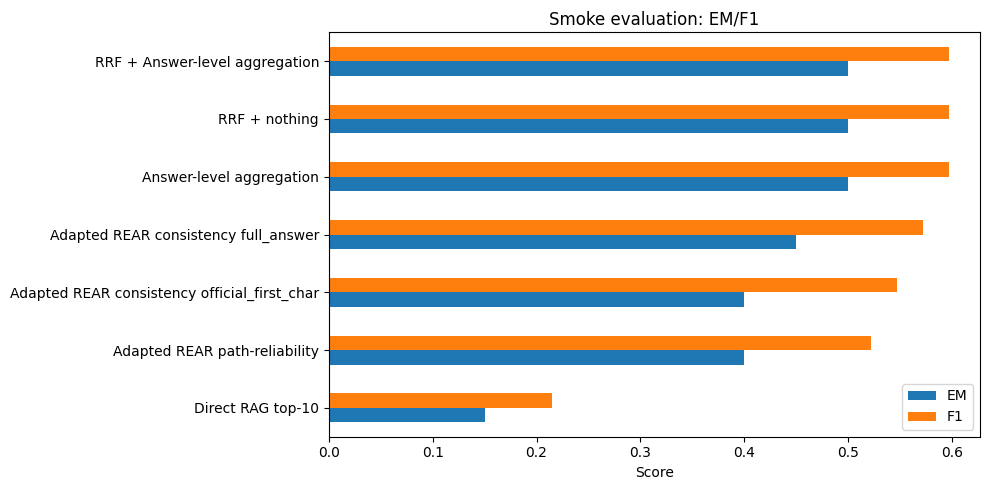

In [28]:
import matplotlib.pyplot as plt

plot_df = summary_smoke.copy()
plot_df = plot_df.sort_values("F1", ascending=True)

ax = plot_df.plot.barh(x="method", y=["EM", "F1"], figsize=(10, 5))
ax.set_title("Smoke evaluation: EM/F1")
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "summary_smoke_em_f1.png", dpi=200)
plt.show()
